# 02 — Diagnóstico de Resíduos e Ljung-Box

Este notebook avalia resíduos exclusivamente fora da amostra. O PLS exporta a data de origem da previsão; como o horizonte é `t+1`, sua data é avançada em um dia para alinhar o resíduo ao valor observado. Modelos sem arquivo de previsão são registrados como pendentes.

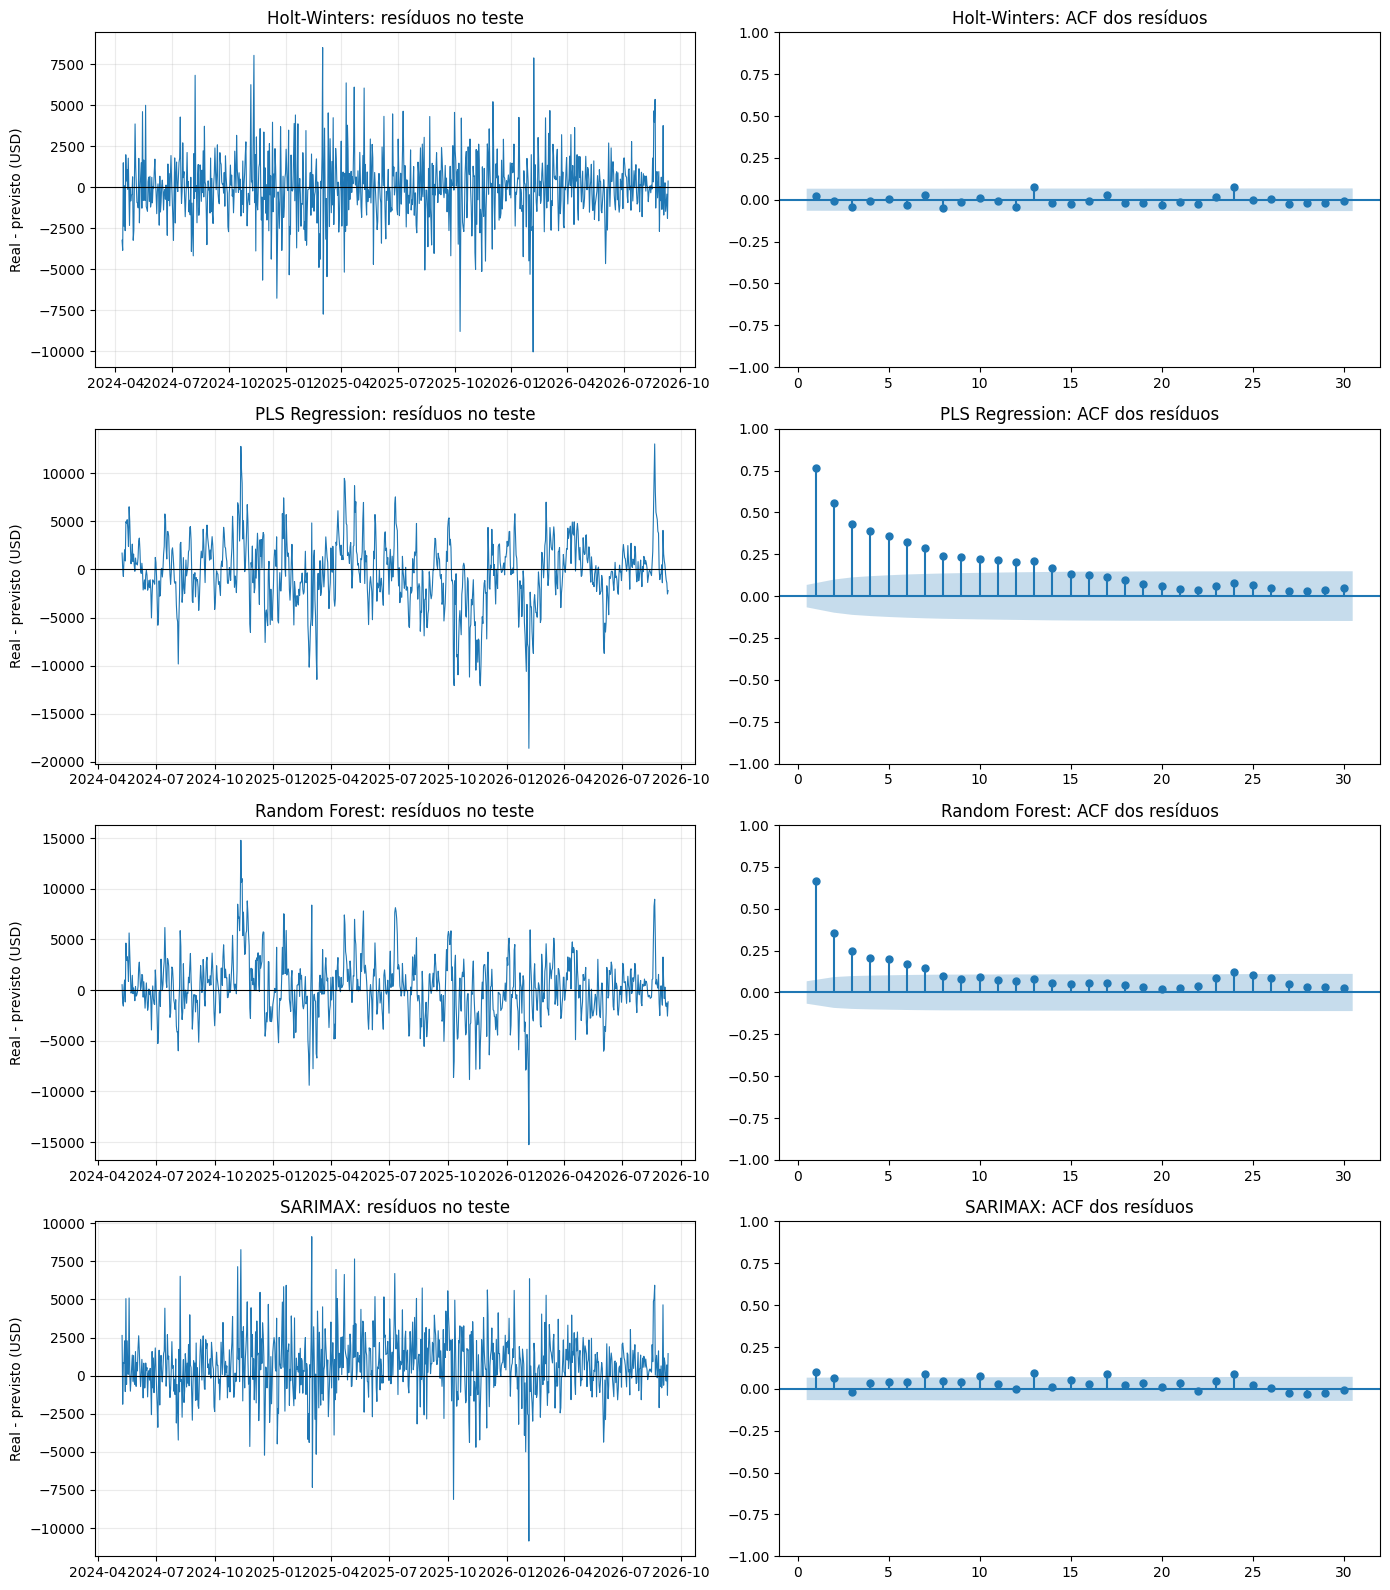

Resumo dos residuos (media diferente de zero indica vies):
        modelo     status  n_residuos  media_residuo  desvio_padrao  p_valor_teste_bias  bias_significativo_5pct
  Holt-Winters Disponivel         883     -11.895804    1961.713097        8.570422e-01                    False
PLS Regression Disponivel         856    -336.247160    3507.804846        5.153253e-03                     True
 Random Forest Disponivel         856     240.770865    2893.632622        1.511892e-02                     True
       SARIMAX Disponivel         856     693.861757    2015.958452        1.288866e-22                     True

Teste Ljung-Box: p < 0,05 indica autocorrelacao residual detectavel.
        modelo  lag  estatistica_Q       p_valor  ruido_branco_5pct
  Holt-Winters    1       0.558098  4.550277e-01               True
  Holt-Winters    3       2.300756  5.123761e-01               True
  Holt-Winters    5       2.371761  7.956718e-01               True
  Holt-Winters    7       4.073007

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

cwd = Path.cwd().resolve()
project_root = next(
    (path for path in (cwd, *cwd.parents)
     if (path / 'analyses').is_dir() and (path / 'bases').is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')

results_dir = project_root / 'analyses' / 'grupo1' / '03_resultados'
model_root = project_root / 'analyses' / 'grupo1' / '02_modelos'
results_dir.mkdir(parents=True, exist_ok=True)

models = {
    'Holt-Winters': (model_root / 'Holt_Winters', 'hw_previsoes_walkforward.csv', 'residuo_HW'),
    'PLS Regression': (model_root / 'PLS_Regression', 'pls_previsoes_walkforward.csv', 'residuo_PLS'),
    'Random Forest': (model_root / 'Random_Forest', 'rf_previsoes_walkforward.csv', 'residuo_RF'),
    'SARIMAX': (model_root / 'SARIMAX', 'sarimax_previsoes_walkforward.csv', 'residuo_SARIMAX'),
}
lags = [1, 3, 5, 7, 14, 21, 30]
residual_frames = {}
summary_rows = []
ljung_box_tables = []

for model_name, (directory, forecast_name, residual_column) in models.items():
    forecast_path = directory / forecast_name
    if not forecast_path.is_file():
        summary_rows.append({
            'modelo': model_name,
            'status': f'Pendente: arquivo ausente ({forecast_name})',
            'n_residuos': 0,
            'media_residuo': np.nan,
            'desvio_padrao': np.nan,
            'p_valor_teste_bias': np.nan,
            'bias_significativo_5pct': pd.NA,
        })
        continue

    frame = pd.read_csv(forecast_path, parse_dates=['date']).sort_values('date')
    if model_name == 'PLS Regression':
        frame['date'] = frame['date'] + pd.Timedelta(days=1)
    if residual_column not in frame:
        raise ValueError(f'{forecast_path} nao contem a coluna {residual_column}.')
    frame = frame[['date', residual_column]].dropna().rename(columns={residual_column: 'residuo'})
    residual_frames[model_name] = frame
    residual = frame['residuo'].astype(float)
    bias_test = ttest_1samp(residual, popmean=0.0)
    summary_rows.append({
        'modelo': model_name,
        'status': 'Disponivel',
        'n_residuos': len(residual),
        'media_residuo': residual.mean(),
        'desvio_padrao': residual.std(ddof=1),
        'p_valor_teste_bias': bias_test.pvalue,
        'bias_significativo_5pct': bool(bias_test.pvalue < 0.05),
    })

    model_lags = [lag for lag in lags if lag < len(residual)]
    lb = acorr_ljungbox(residual, lags=model_lags, return_df=True)
    lb = lb.rename(columns={'lb_stat': 'estatistica_Q', 'lb_pvalue': 'p_valor'})
    lb.index.name = 'lag'
    lb = lb.reset_index()
    lb.insert(0, 'modelo', model_name)
    lb['ruido_branco_5pct'] = lb['p_valor'] >= 0.05
    ljung_box_tables.append(lb)

residuos_resumo = pd.DataFrame(summary_rows)
residuos_resumo.to_csv(results_dir / 'residuos_resumo.csv', index=False)
if ljung_box_tables:
    ljung_box_consolidado = pd.concat(ljung_box_tables, ignore_index=True)
else:
    ljung_box_consolidado = pd.DataFrame(columns=['modelo', 'lag', 'estatistica_Q', 'p_valor', 'ruido_branco_5pct'])
ljung_box_consolidado.to_csv(results_dir / 'ljung_box_consolidado.csv', index=False)

available = list(residual_frames.items())
if available:
    fig, axes = plt.subplots(len(available), 2, figsize=(14, 4 * len(available)), squeeze=False)
    for row_index, (model_name, frame) in enumerate(available):
        residual = frame['residuo'].astype(float)
        axes[row_index, 0].plot(frame['date'], residual, linewidth=0.8)
        axes[row_index, 0].axhline(0, color='black', linewidth=0.8)
        axes[row_index, 0].set_title(f'{model_name}: resíduos no teste')
        axes[row_index, 0].set_ylabel('Real - previsto (USD)')
        axes[row_index, 0].grid(alpha=0.25)
        plot_acf(residual, lags=min(30, len(residual) - 1), ax=axes[row_index, 1], zero=False)
        axes[row_index, 1].set_title(f'{model_name}: ACF dos resíduos')
    fig.tight_layout()
    fig.savefig(results_dir / '02_residuos_acf.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nenhum arquivo de previsoes disponivel para diagnostico.')

print('Resumo dos residuos (media diferente de zero indica vies):')
print(residuos_resumo.to_string(index=False))
print('\nTeste Ljung-Box: p < 0,05 indica autocorrelacao residual detectavel.')
print(ljung_box_consolidado.to_string(index=False))

## Interpretação

A média dos resíduos resume o viés (resíduo definido como real menos previsto); o teste t avalia se ela difere de zero. No Ljung-Box, rejeitar a hipótese nula indica dependência temporal ainda presente. A não rejeição não prova independência nem normalidade.